# Chargement des données d’images

Jusqu’à présent, nous avons travaillé avec des ensembles de données assez artificiels, peu représentatifs des projets réels.  
Dans la pratique, vous serez souvent amené à manipuler des **images de grande taille**, comme celles issues d’appareils photo ou de téléphones portables.  
Dans ce notebook, nous verrons comment **charger des images** et les utiliser pour **entraîner des réseaux de neurones**.

Nous utiliserons un [jeu de données de photos de chats et de chiens](https://www.kaggle.com/c/dogs-vs-cats) disponible sur **Kaggle**.  
Voici quelques exemples d’images :



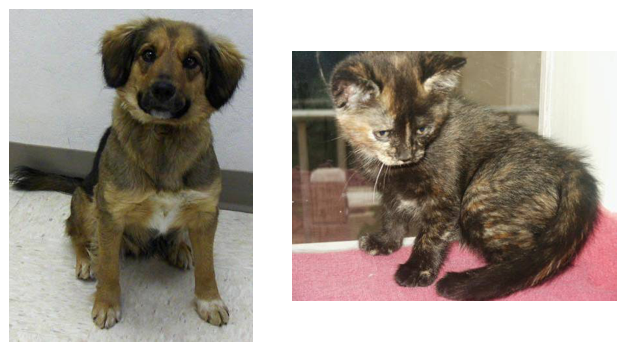

Nous emploierons ce jeu de données pour entraîner un réseau de neurones capable de **distinguer les chats des chiens**.  
Aujourd’hui, cela peut sembler banal, mais il y a encore quelques années, c’était un véritable **défi pour les systèmes de vision par ordinateur**.

In [ ]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

from pathlib import Path
import os
import random
import urllib.request
import zipfile

import matplotlib.pyplot as plt
import numpy as np

import torch
from torch import nn, optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models

try:
    import helper
except ModuleNotFoundError:
    import my_helper as helper



La façon la plus simple de charger des images est d’utiliser `datasets.ImageFolder` de la bibliothèque **torchvision** ([documentation](http://pytorch.org/docs/master/torchvision/datasets.html#imagefolder)).  
En général, vous utiliserez `ImageFolder` comme ceci :

```python
dataset = datasets.ImageFolder('path/to/data', transform=transform)
```

où `'path/to/data'` est le chemin d’accès au répertoire contenant les données, et `transform` est une **séquence d’opérations de prétraitement** définies à l’aide du module [`transforms`](http://pytorch.org/docs/master/torchvision/transforms.html) de `torchvision`.

`ImageFolder` s’attend à une structure de répertoires comme celle-ci :

```
root/dog/xxx.png
root/dog/xxy.png
root/dog/xxz.png

root/cat/123.png
root/cat/nsdf3.png
root/cat/asd932_.png
```

Chaque classe (ici `cat` et `dog`) possède son **propre dossier** contenant les images correspondantes.
Les images sont alors automatiquement **étiquetées** d’après le nom du dossier.
Ainsi, l’image `123.png` sera chargée avec l’étiquette `cat`.

Vous pouvez télécharger le jeu de données déjà structuré de cette manière [ici](https://s3.amazonaws.com/content.udacity-data.com/nd089/Cat_Dog_data.zip).
Il est déjà séparé en **jeu d’entraînement** et **jeu de test**.

---

### 🔄 Transformations

Lors du chargement des données avec `ImageFolder`, il faut définir des **transformations (transforms)**.
Par exemple, les images ont des tailles différentes, mais le modèle nécessite qu’elles aient toutes la même taille pour l’entraînement.
On peut donc :

* les **redimensionner** avec `transforms.Resize()`, ou
* les **rogner** avec `transforms.CenterCrop()` ou `transforms.RandomResizedCrop()`.

Il faut également **convertir les images en tenseurs PyTorch** à l’aide de `transforms.ToTensor()`.

En général, ces étapes sont combinées en un pipeline à l’aide de `transforms.Compose()`, qui exécute une liste de transformations dans l’ordre.
Par exemple, pour redimensionner, recadrer, puis convertir en tenseur :

```python
transform = transforms.Compose([
    transforms.Resize(255),
    transforms.CenterCrop(224),
    transforms.ToTensor()
])
```

Il existe de nombreuses autres transformations possibles — consultez la [documentation](http://pytorch.org/docs/master/torchvision/transforms.html) pour plus de détails.

---

### 📦 Data Loaders

Une fois le `ImageFolder` chargé, il faut le passer à un [`DataLoader`](http://pytorch.org/docs/master/data.html#torch.utils.data.DataLoader).
Le **DataLoader** prend un dataset (par exemple celui renvoyé par `ImageFolder`) et retourne des **lots (batches)** d’images et leurs **étiquettes** correspondantes.
Vous pouvez régler plusieurs paramètres, comme :

* la **taille des lots (`batch_size`)**,
* et le **mélange des données (`shuffle`)** à chaque époque.

Exemple :

```python
dataloader = torch.utils.data.DataLoader(dataset, batch_size=32, shuffle=True)
```

L’objet `dataloader` est un **générateur**.
Pour extraire des données, on peut soit boucler dessus, soit le convertir en itérateur et appeler `next()` :

```python
# Boucle pour récupérer un batch à chaque itération
for images, labels in dataloader:
    pass

# Obtenir un seul batch
images, labels = next(iter(dataloader))
```

---

> **Exercice :**
> Chargez les images depuis le dossier `Cat_Dog_data/train`,
> définissez quelques transformations,
> puis construisez le **DataLoader**.



In [ ]:
# Optionnel: monter Google Drive si le notebook est execute dans Colab.
try:
    from google.colab import drive
    drive.mount('/content/drive')
except Exception:
    print("Hors Colab: montage Google Drive ignore.")


In [ ]:
PROJECT_DIR = Path.cwd()
print(f"Repertoire courant: {PROJECT_DIR}")


In [ ]:
print("Fichiers presents:")
for item in sorted(PROJECT_DIR.iterdir()):
    print("-", item.name)


In [ ]:
# Telechargement/extraction automatique du dataset si necessaire.
DATA_URL = "https://s3.amazonaws.com/content.udacity-data.com/nd089/Cat_Dog_data.zip"
DATA_ZIP = Path("Cat_Dog_data.zip")
DATA_DIR = Path("Cat_Dog_data")

if not DATA_DIR.exists():
    if not DATA_ZIP.exists():
        print("Telechargement du dataset Cats vs Dogs...")
        urllib.request.urlretrieve(DATA_URL, DATA_ZIP)
    print("Extraction du dataset...")
    with zipfile.ZipFile(DATA_ZIP, "r") as zf:
        zf.extractall(".")
else:
    print("Dataset deja present.")


In [ ]:
data_dir = 'Cat_Dog_data/train'

transform = transforms.Compose([
    transforms.Resize(255),
    transforms.CenterCrop(224),
    transforms.ToTensor()
])

dataset = datasets.ImageFolder(data_dir, transform=transform)
dataloader = torch.utils.data.DataLoader(
    dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

print(dataset.classes)
print(f"Nombre d'images d'entrainement: {len(dataset)}")


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch

def imshow(image, ax=None, title=None, normalize=True):
    """Imshow for Tensor."""
    if ax is None:
        fig, ax = plt.subplots()

    image = image.numpy().transpose((1, 2, 0))

    if normalize:
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        image = std * image + mean
        image = np.clip(image, 0, 1)

    ax.imshow(image)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.tick_params(axis='both', length=0)
    ax.set_xticklabels('')
    ax.set_yticklabels('')

    return ax

In [ ]:
# Run this to test your data loader
images, labels = next(iter(dataloader))
imshow(images[0], normalize=False)

Si vous avez correctement chargé les données, vous devriez obtenir un affichage similaire à celui-ci (votre image sera différente) :




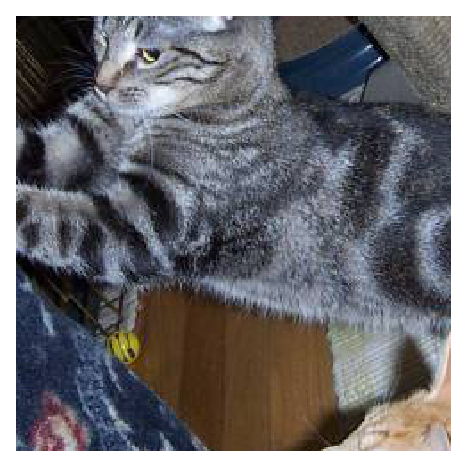


## Augmentation de Données

Une stratégie courante pour entraîner des réseaux de neurones consiste à introduire une **certaine forme d’aléatoire dans les données d’entrée**.  
Par exemple, on peut faire tourner, refléter, redimensionner et/ou rogner aléatoirement les images pendant l’entraînement.  
Cela aide le réseau à **mieux généraliser**, car il voit les mêmes images sous différentes formes : positions, tailles, orientations, etc.

Pour appliquer une rotation, un recadrage et un redimensionnement aléatoires, puis retourner les images horizontalement, on peut définir les transformations ainsi :

```python
train_transforms = transforms.Compose([
    transforms.RandomRotation(30),
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5],
                         [0.5, 0.5, 0.5])
])
```

Il est également recommandé de **normaliser les images** à l’aide de `transforms.Normalize`.
Cette transformation prend en entrée :

* une liste de **moyennes** (`mean`)
* et une liste d’**écarts-types** (`std`)

Chaque canal de couleur est alors normalisé selon la formule :

```
input[channel] = (input[channel] - mean[channel]) / std[channel]
```

Soustraire la moyenne recentre les données autour de zéro,
et diviser par l’écart-type comprime les valeurs entre **-1 et 1**.
Cette normalisation aide à maintenir les **poids du réseau proches de zéro**,
rendant ainsi la **rétropropagation plus stable**.
Sans normalisation, le réseau risque souvent d’échouer à apprendre correctement.

Vous pouvez consulter la **liste complète des transformations disponibles** [ici](http://pytorch.org/docs/0.3.0/torchvision/transforms.html).

Lors des phases de **validation** ou de **test**, on utilise généralement des images **non altérées** (hormis la normalisation).
Ainsi, pour les données de validation ou de test, on se contente en général de **redimensionner** et **recadrer** les images.

---

> **Exercice :**
> Définissez ci-dessous les **transformations** pour les données d’entraînement et de test.
> Ne mettez pas encore la normalisation.



In [ ]:
data_dir = 'Cat_Dog_data'

# Transformations sans normalisation, comme demande dans l'enonce de cette cellule.
train_transforms = transforms.Compose([
    transforms.RandomRotation(30),
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor()
])

test_transforms = transforms.Compose([
    transforms.Resize(255),
    transforms.CenterCrop(224),
    transforms.ToTensor()
])

# Pass transforms in here, then run the next cell to see how the transforms look
train_data = datasets.ImageFolder(data_dir + '/train', transform=train_transforms)
test_data = datasets.ImageFolder(data_dir + '/test', transform=test_transforms)

trainloader = torch.utils.data.DataLoader(
    train_data,
    batch_size=32,
    shuffle=True,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)
testloader = torch.utils.data.DataLoader(
    test_data,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)


In [ ]:
# change this to the trainloader or testloader
data_iter = iter(trainloader)

In [ ]:
images, labels = next(data_iter)
labels

In [ ]:


images, labels = next(data_iter)
fig, axes = plt.subplots(figsize=(10,4), ncols=4)
for ii in range(4):
    ax = axes[ii]
    imshow(images[ii], ax=ax, normalize=False)

Vos images transformées devraient ressembler à quelque chose comme ceci.




<center>Training examples:</center>


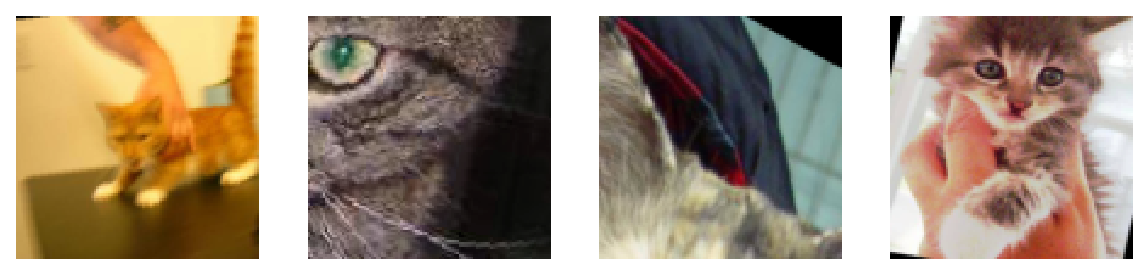

<center>Testing examples:</center>

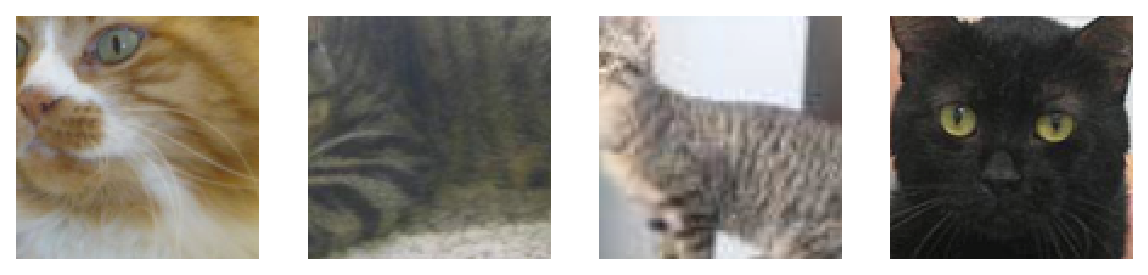


À ce stade, vous devriez être en mesure de charger les données pour l’entraînement et le test.  
Vous pouvez maintenant essayer de construire un réseau capable de **classer les chats et les chiens**.



In [ ]:
# Premier modele CNN from scratch: la version complete et entrainee est definie plus bas.
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=2, dropout=0.5):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        return self.classifier(x)

simple_model = SimpleCNN(num_classes=2)
print(simple_model)


# TP – CNN “from scratch” vs Transfert Learning (Cats vs Dogs)

## Objectif

Comparer **un modèle CNN entraîné from scratch** et **un modèle en transfert d’apprentissage** sur le même jeu de données (cats vs dogs). Montrer l’impact du transfert learning sur la convergence, la performance et la robustesse.

## Ce qui est **obligatoire**

1. **Deux expériences distinctes**

   * Expérience A : CNN **from scratch** (architecture simple minimum 3 bloc avec conv).
   * Expérience B : **Transfert learning** (ex. ResNet, MobileNet, EfficientNet…), couches finales adaptées.
2. **Bonnes pratiques de régularisation**

   * Utiliser **Dropout** ET **Batch Normalization** (justifier où et pourquoi).
3. **Suivi des métriques**

   * **Training loss**, **Accuracy**, **Précision**, **Recall** à chaque époque (et idéalement sur train/val si vous faites une validation).
   * Tracer des **courbes** et **comparer** les deux approches.
4. **Optimisation**

   * Tester au moins **2 optimiseurs** (ex. SGD et Adam).
   * Chercher un **bon learning rate** (essais ou scheduler).
5. **GPU**

   * Entraîner **sur GPU** si disponible (vérification et mention dans README).
6. **Persistance du modèle**

   * **Sauvegarder** le meilleur modèle (.pt/.pth) localement (ne **pas** pousser dans GitHub).
   * **Recharger** le modèle pour faire le **test final** et rapporter les métriques.
7. **Reproductibilité**

   * Fixer un **seed**

## Ce qui est **souhaité (bonus)**

* **Split train/validation** (clair et justifié).
* **Data augmentation** raisonnable.
* **Scheduler** (ex. StepLR, CosineAnnealingLR).
* **Matrice de confusion** et quelques **erreurs typiques** commentées.
* Journalisation (TensorBoard/W&B) — sans pousser les fichiers lourds.

## Données

* Utilisez le même corpus **Cats vs Dogs** que vu en cours (ou équivalent).
* Ne **poussez pas** les données sur GitHub. Indiquez seulement **comment** les télécharger/placer.

## Structure du dépôt GitHub (exemple)

```
cnn-catsdogs-<NomPrenom>/
├─ notebook.ipynb
├─ .gitignore
├─ requirements.txt (ou environment.yml)
├─ README.md
└─ LICENSE (optionnel)
```

### `.gitignore` (minimum)

```
data/
*.pt
*.pth
runs/
checkpoints/
```

## Contenu attendu du **README.md**

* **Titre & objectif** du projet.
* **Environnement** ( `pip install -r requirements.txt` ou `conda env create -f environment.yml`).
* **Organisation des données** (où télécharger, où placer les dossiers).
* **Commandes pour entraîner** :

  * From scratch : arguments clés (batch size, lr, epochs, optimiser, dropout, BN, scheduler…).
  * Transfert learning : même chose + quelle base (gel des couches ou fine-tuning).
* **Commandes pour évaluer / recharger le modèle** (chemin du checkpoint local).
* **Résultats** : tableaux + courbes (loss/accuracy/précision/recall) pour les deux expériences, **comparaison et analyse** (2–3 paragraphes).
* **Limites & pistes d’amélioration** (brèves).

## Évaluation (grille indicative)

* Rigueur expérimentale & métriques (30 %)
* Qualité des modèles & optimisation (25 %)
* Clarté du code & structure du dépôt (20 %)
* README (reproductibilité, analyse, figures) (20 %)
* Bonus (val split, augmentation, scheduler, confusion matrix) (5 %)

## Remise

* **Poussez votre code sur GitHub** (sans données ni modèles).
* Envoyez **le lien du dépôt** à **[diallomous@gmail.com](mailto:diallomous@gmail.com)**
* **Date limite : jeud  04/juin/2026 avant 23h00. (Africa/Dakar).**

> Rappel : ne chargez pas les fichiers lourds (datasets, `.pt/.pth`). Assurez-vous que votre dépôt permet de **reproduire** les expériences via les instructions du README.


# Solution expérimentale complète

Cette section répond aux consignes du TP : comparaison entre un CNN entraîné **à partir de zéro** et un modèle en **apprentissage par transfert**, avec deux optimiseurs, suivi des métriques, sauvegarde/rechargement du meilleur modèle et visualisations.


In [ ]:
# Reproductibilite et configuration generale
SEED = 42
BATCH_SIZE = 32
IMAGE_SIZE = 224
VAL_RATIO = 0.20
NUM_CLASSES = 2
CHECKPOINT_DIR = Path("checkpoints")
CHECKPOINT_DIR.mkdir(exist_ok=True)


def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Appareil utilise: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")


In [ ]:
# Transformation avec normalisation pour l'entrainement final.
# La normalisation ImageNet est necessaire pour l'apprentissage par transfert avec ResNet.
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

experiment_train_transforms = transforms.Compose([
    transforms.RandomRotation(25),
    transforms.RandomResizedCrop(IMAGE_SIZE, scale=(0.75, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std),
])

experiment_eval_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std),
])

train_root = DATA_DIR / "train"
test_root = DATA_DIR / "test"

train_augmented_data = datasets.ImageFolder(train_root, transform=experiment_train_transforms)
train_eval_data = datasets.ImageFolder(train_root, transform=experiment_eval_transforms)
test_data_final = datasets.ImageFolder(test_root, transform=experiment_eval_transforms)
class_names = train_augmented_data.classes
print("Classes:", class_names)


In [ ]:
# Decoupage entrainement/validation stratifie pour garder la proportion chats/chiens.
targets = np.array(train_augmented_data.targets)
rng = np.random.default_rng(SEED)
train_indices = []
val_indices = []

for class_id in np.unique(targets):
    class_indices = np.where(targets == class_id)[0]
    rng.shuffle(class_indices)
    split_at = int((1 - VAL_RATIO) * len(class_indices))
    train_indices.extend(class_indices[:split_at].tolist())
    val_indices.extend(class_indices[split_at:].tolist())

rng.shuffle(train_indices)
rng.shuffle(val_indices)

train_subset = Subset(train_augmented_data, train_indices)
val_subset = Subset(train_eval_data, val_indices)

loader_kwargs = {
    "batch_size": BATCH_SIZE,
    "num_workers": 2,
    "pin_memory": torch.cuda.is_available(),
}

trainloader_final = DataLoader(train_subset, shuffle=True, drop_last=True, **loader_kwargs)
valloader_final = DataLoader(val_subset, shuffle=False, **loader_kwargs)
testloader_final = DataLoader(test_data_final, shuffle=False, **loader_kwargs)

print(f"Entrainement: {len(train_subset)} images")
print(f"Validation: {len(val_subset)} images")
print(f"Test: {len(test_data_final)} images")


## Régularisation utilisée

* La **normalisation par lot** est placée après les convolutions du CNN entraîné à partir de zéro pour stabiliser les distributions d'activations et accélérer l'apprentissage.
* La **désactivation aléatoire** est placée dans les couches de classification, là où le risque de surapprentissage est fort car les couches entièrement connectées apprennent des combinaisons très spécifiques.
* En apprentissage par transfert, les couches convolutives pré-entraînées de ResNet18 sont gelées; on régularise surtout la tête de classification ajoutée.


In [ ]:
class ScratchCNN(nn.Module):
    """CNN simple entraine a partir de zero avec 4 blocs convolutionnels."""

    def __init__(self, num_classes=NUM_CLASSES, dropout=0.5):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        return self.classifier(x)


def build_scratch_model():
    return ScratchCNN(num_classes=NUM_CLASSES, dropout=0.5)


def build_transfer_model():
    weights = models.ResNet18_Weights.DEFAULT
    model = models.resnet18(weights=weights)

    for param in model.parameters():
        param.requires_grad = False

    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.BatchNorm1d(in_features),
        nn.Dropout(0.4),
        nn.Linear(in_features, NUM_CLASSES),
    )
    return model


scratch_model = build_scratch_model()
transfer_model = build_transfer_model()
print("Parametres entrainables - modele a partir de zero:", sum(p.numel() for p in scratch_model.parameters() if p.requires_grad))
print("Parametres entrainables - apprentissage par transfert:", sum(p.numel() for p in transfer_model.parameters() if p.requires_grad))


In [ ]:
def metrics_from_predictions(preds, labels, num_classes=NUM_CLASSES):
    preds = torch.as_tensor(preds).cpu().long()
    labels = torch.as_tensor(labels).cpu().long()
    cm = torch.zeros((num_classes, num_classes), dtype=torch.long)

    for target, pred in zip(labels, preds):
        cm[target, pred] += 1

    total = cm.sum().item()
    accuracy = cm.diag().sum().item() / max(total, 1)

    diag = cm.diag().float()
    precision_per_class = diag / cm.sum(dim=0).clamp(min=1).float()
    recall_per_class = diag / cm.sum(dim=1).clamp(min=1).float()

    return {
        "accuracy": accuracy,
        "precision": precision_per_class.mean().item(),
        "recall": recall_per_class.mean().item(),
        "confusion_matrix": cm,
    }


def run_epoch(model, dataloader, criterion, optimizer=None):
    is_training = optimizer is not None
    model.train(is_training)

    running_loss = 0.0
    all_preds = []
    all_labels = []

    for images, labels in dataloader:
        images = images.to(device)
        labels = labels.to(device)

        if is_training:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(is_training):
            logits = model(images)
            loss = criterion(logits, labels)
            if is_training:
                loss.backward()
                optimizer.step()

        running_loss += loss.item() * labels.size(0)
        all_preds.extend(logits.argmax(dim=1).detach().cpu().tolist())
        all_labels.extend(labels.detach().cpu().tolist())

    metrics = metrics_from_predictions(all_preds, all_labels)
    metrics["loss"] = running_loss / len(dataloader.dataset)
    return metrics


def make_optimizer(model, name="adam", lr=1e-3, weight_decay=1e-4):
    params = [p for p in model.parameters() if p.requires_grad]
    name = name.lower()
    if name == "adam":
        return optim.Adam(params, lr=lr, weight_decay=weight_decay)
    if name == "sgd":
        return optim.SGD(params, lr=lr, momentum=0.9, weight_decay=weight_decay)
    raise ValueError(f"Optimiseur inconnu: {name}")


def fit_model(model, model_type, optimizer_name, lr, epochs, checkpoint_path):
    criterion = nn.CrossEntropyLoss()
    optimizer = make_optimizer(model, name=optimizer_name, lr=lr)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.5)

    history = []
    best_val_acc = -1.0

    for epoch in range(1, epochs + 1):
        train_metrics = run_epoch(model, trainloader_final, criterion, optimizer=optimizer)
        val_metrics = run_epoch(model, valloader_final, criterion, optimizer=None)
        scheduler.step()

        row = {"epoch": epoch}
        for key in ["loss", "accuracy", "precision", "recall"]:
            row[f"train_{key}"] = train_metrics[key]
            row[f"val_{key}"] = val_metrics[key]
        history.append(row)

        if val_metrics["accuracy"] > best_val_acc:
            best_val_acc = val_metrics["accuracy"]
            torch.save(
                {
                    "model_type": model_type,
                    "model_state": model.state_dict(),
                    "optimizer_name": optimizer_name,
                    "lr": lr,
                    "epoch": epoch,
                    "best_val_accuracy": best_val_acc,
                    "class_to_idx": train_augmented_data.class_to_idx,
                    "class_names": class_names,
                    "history": history,
                },
                checkpoint_path,
            )

        print(
            f"Epoque {epoch:02d}/{epochs} | "
            f"entrainement perte={train_metrics['loss']:.4f}, exactitude={train_metrics['accuracy']:.3f}, "
            f"precision={train_metrics['precision']:.3f}, rappel={train_metrics['recall']:.3f} | "
            f"validation perte={val_metrics['loss']:.4f}, exactitude={val_metrics['accuracy']:.3f}, "
            f"precision={val_metrics['precision']:.3f}, rappel={val_metrics['recall']:.3f}"
        )

    return history, checkpoint_path


In [ ]:
# Lancement des experiences.
# Ajustez le nombre d'epoques si vous avez peu de temps; gardez les memes valeurs pour comparer proprement.
EXPERIMENTS = [
    {"name": "scratch_adam", "model_type": "scratch", "builder": build_scratch_model, "optimizer": "adam", "lr": 1e-3, "epochs": 8},
    {"name": "scratch_sgd", "model_type": "scratch", "builder": build_scratch_model, "optimizer": "sgd", "lr": 1e-2, "epochs": 8},
    {"name": "transfer_adam", "model_type": "transfer", "builder": build_transfer_model, "optimizer": "adam", "lr": 1e-3, "epochs": 5},
    {"name": "transfer_sgd", "model_type": "transfer", "builder": build_transfer_model, "optimizer": "sgd", "lr": 1e-2, "epochs": 5},
]

histories = {}
checkpoint_paths = {}

for cfg in EXPERIMENTS:
    print("\n" + "=" * 80)
    print(f"Experience: {cfg['name']}")
    print("=" * 80)
    set_seed(SEED)
    model = cfg["builder"]().to(device)
    checkpoint_path = CHECKPOINT_DIR / f"{cfg['name']}_best.pth"
    history, saved_path = fit_model(
        model=model,
        model_type=cfg["model_type"],
        optimizer_name=cfg["optimizer"],
        lr=cfg["lr"],
        epochs=cfg["epochs"],
        checkpoint_path=checkpoint_path,
    )
    histories[cfg["name"]] = history
    checkpoint_paths[cfg["name"]] = saved_path


In [ ]:
def summarize_histories(histories):
    rows = []
    for name, history in histories.items():
        best = max(history, key=lambda row: row["val_accuracy"])
        rows.append({
            "experience": name,
            "best_epoch": best["epoch"],
            "train_loss": best["train_loss"],
            "val_loss": best["val_loss"],
            "val_accuracy": best["val_accuracy"],
            "val_precision": best["val_precision"],
            "val_recall": best["val_recall"],
        })
    return rows

summary_rows = summarize_histories(histories)
try:
    import pandas as pd
    summary_df = pd.DataFrame(summary_rows).sort_values("val_accuracy", ascending=False)
    display(summary_df)
except Exception:
    for row in sorted(summary_rows, key=lambda r: r["val_accuracy"], reverse=True):
        print(row)


In [ ]:
def plot_metric(histories, metric):
    plt.figure(figsize=(10, 5))
    for name, history in histories.items():
        epochs = [row["epoch"] for row in history]
        train_values = [row[f"train_{metric}"] for row in history]
        val_values = [row[f"val_{metric}"] for row in history]
        plt.plot(epochs, train_values, linestyle="--", label=f"{name} entrainement")
        plt.plot(epochs, val_values, label=f"{name} validation")
    plt.title(metric.capitalize())
    plt.xlabel("Epoque")
    plt.ylabel(metric)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()

for metric in ["loss", "accuracy", "precision", "recall"]:
    plot_metric(histories, metric)


In [ ]:
def build_model_by_type(model_type):
    if model_type == "scratch":
        return build_scratch_model()
    if model_type == "transfer":
        return build_transfer_model()
    raise ValueError(f"Type de modele inconnu: {model_type}")


def load_model_from_checkpoint(path):
    payload = torch.load(path, map_location=device)
    model = build_model_by_type(payload["model_type"])
    model.load_state_dict(payload["model_state"])
    model.to(device)
    model.eval()
    return model, payload

best_experience = max(summary_rows, key=lambda row: row["val_accuracy"])["experience"]
best_checkpoint = checkpoint_paths[best_experience]
best_model, best_payload = load_model_from_checkpoint(best_checkpoint)
print(f"Meilleur modele recharge: {best_experience}")
print(f"Point de sauvegarde: {best_checkpoint}")
print(f"Meilleure exactitude en validation: {best_payload['best_val_accuracy']:.3f}")

test_metrics = run_epoch(best_model, testloader_final, nn.CrossEntropyLoss(), optimizer=None)
print("Metriques finales sur test:")
for key in ["loss", "accuracy", "precision", "recall"]:
    print(f"{key}: {test_metrics[key]:.4f}")


In [ ]:
def plot_confusion_matrix(cm, class_names):
    cm = cm.cpu().numpy()
    fig, ax = plt.subplots(figsize=(5, 4))
    im = ax.imshow(cm, cmap="Blues")
    ax.set_xticks(np.arange(len(class_names)))
    ax.set_yticks(np.arange(len(class_names)))
    ax.set_xticklabels(class_names)
    ax.set_yticklabels(class_names)
    ax.set_xlabel("Prediction")
    ax.set_ylabel("Vraie classe")
    ax.set_title("Matrice de confusion - test")

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, int(cm[i, j]), ha="center", va="center", color="black")
    fig.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.show()

plot_confusion_matrix(test_metrics["confusion_matrix"], class_names)


In [ ]:
def denormalize(image, mean=imagenet_mean, std=imagenet_std):
    image = image.detach().cpu().clone()
    mean = torch.tensor(mean).view(3, 1, 1)
    std = torch.tensor(std).view(3, 1, 1)
    image = image * std + mean
    return image.clamp(0, 1)


def show_misclassified(model, dataset, class_names, max_images=6):
    model.eval()
    mistakes = []
    with torch.no_grad():
        for idx in range(len(dataset)):
            image, label = dataset[idx]
            logits = model(image.unsqueeze(0).to(device))
            pred = logits.argmax(dim=1).item()
            if pred != label:
                mistakes.append((image, label, pred))
            if len(mistakes) >= max_images:
                break

    if not mistakes:
        print("Aucune erreur trouvee dans les premiers exemples parcourus.")
        return

    fig, axes = plt.subplots(1, len(mistakes), figsize=(3 * len(mistakes), 3))
    if len(mistakes) == 1:
        axes = [axes]
    for ax, (image, label, pred) in zip(axes, mistakes):
        img = denormalize(image).permute(1, 2, 0).numpy()
        ax.imshow(img)
        ax.set_title(f"Vrai: {class_names[label]}\nPred: {class_names[pred]}")
        ax.axis("off")
    plt.tight_layout()
    plt.show()

show_misclassified(best_model, test_data_final, class_names)


## Analyse à rédiger après exécution

Après avoir exécuté les cellules d'entraînement, utilisez le tableau récapitulatif, les courbes et la matrice de confusion pour compléter le README avec les valeurs exactes. L'analyse attendue doit comparer :

* la vitesse de convergence du CNN entraîné à partir de zéro et de l'apprentissage par transfert;
* l'effet des optimiseurs Adam et SGD;
* le niveau de surapprentissage visible entre les courbes entraînement/validation;
* les erreurs typiques observées dans les images mal classées.

Normalement, l'apprentissage par transfert converge plus vite car ResNet18 possède déjà des filtres visuels génériques appris sur ImageNet. Le CNN entraîné à partir de zéro peut progresser, mais il demande plus d'époques et plus de données pour atteindre une performance comparable.
